 # Step 5 — Validation of the Optimizer (v2)

Цель этого ноутбука — проверить, что uplift +26%…+93% из Шага 4 не артефакт смещённой модели спроса или нереалистичных промо-долей.

## Roadmap

| Section | Что проверяем | Антидот к красному флагу |
|---|---|---|
| 0 | Setup, загрузка артефактов | — |
| 1 | **Counterfactual replay** — на строках где recommended ≈ historical, predicted q_hat должен ≈ actual UNITS | Selection bias в GBM baseline |
| 2 | **Calibration** — predicted profit vs actual по decile | Monotonicity и масштаб профита |
| 3 | **Capacity-constrained re-run** — hard caps на доли promo (none ≤ 75.7%, tpr ≤ 11.1%, ...) | Нереалистичное распределение promo |
| 4 | **Simulated α-rollout** — блендим recommended × historical price, пересчитываем q, кривая profit(α) | Риск осторожной выкатки |
| 5 | **Narrative**: generalization to beauty retail + caveats | Портфолио-нарратив |

Используемые артефакты в `data/artifacts/` (v2 версии).


In [1]:
# === Cell 1: imports + load v2 artifacts ===
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

ARTIFACTS = Path('data') / 'artifacts'

# --- Data (v2 with realistic cost) ---
test_df = pd.read_parquet(ARTIFACTS / 'test_v2.parquet').reset_index(drop=True)
test_df['test_row_id'] = np.arange(len(test_df))
sku_info = pd.read_parquet(ARTIFACTS / 'sku_info_v2.parquet')

# Per-policy recommendations и полный bundle predicted q/profit
recommendations = pd.read_parquet(ARTIFACTS / 'recommendations_per_sku.parquet')
candidates = pd.read_parquet(ARTIFACTS / 'candidates_v2_with_q.parquet')

# Multi-policy report из Шага 4 (для последующего сравнения)
report_step4 = pd.read_parquet(ARTIFACTS / 'multi_policy_report.parquet')

# --- Models ---
gbm_demand = joblib.load(ARTIFACTS / 'gbm_demand.pkl')
cf_dml_a   = joblib.load(ARTIFACTS / 'cf_dml_model_a.pkl')  # Model A — чистая ценовая

# --- Causal estimates / constants ---
with open(ARTIFACTS / 'promo_lift.json') as f:
    promo_lift_log = json.load(f)  # dict promo_type -> log lift vs 'none'

EFFECT_MODIFIERS = ['manuf_code', 'subcat_code', 'seg_code', 'size_oz']
PROMO_ORDER = ['none', 'tpr', 'display', 'feature', 'feature_display']

print(f'test_df         : {test_df.shape}')
print(f'recommendations : {recommendations.shape}  (policies: {sorted(recommendations["policy"].unique())})')
print(f'candidates      : {candidates.shape}')
print(f'sku_info        : {sku_info.shape}')
print(f'promo_lift_log  : {promo_lift_log}')
print(f'gbm features    : {len(gbm_demand.feature_name_)}')


test_df         : (19004, 44)
recommendations : (95020, 20)  (policies: ['greedy_i', 'growth_i', 'growth_ii', 'mixture', 'per_category_30pct'])
candidates      : (1807861, 16)
sku_info        : (15, 13)
promo_lift_log  : {'none': 0.0, 'tpr': -0.069, 'display': 0.356, 'feature': 0.357, 'feature_display': 0.727}
gbm features    : 18


In [2]:
# === Cell 2: sanity — recap элементов из Шага 4 ===
print('--- test_df: ключевые поля ---')
print(test_df[['UNITS', 'PRICE', 'cost', 'promo_type', 'is_underwater']].describe(include='all').T)
print()

print('--- promo_type distribution (test) — будем использовать как CAPACITY caps ---')
promo_share_hist = test_df['promo_type'].value_counts(normalize=True).reindex(PROMO_ORDER).fillna(0.0)
print(promo_share_hist.round(4))
print()

print('--- Step 4 multi-policy report (для reference) ---')
print(report_step4.round(2).to_string(index=False))
print()

# Sanity mean elasticity (по test) — должно быть ≈ −1.80 (как в README)
em = test_df[EFFECT_MODIFIERS].values
eps_point = cf_dml_a.effect(em)
print(f'cf_dml_a mean elasticity on test : {eps_point.mean():.3f} '
      f'(range [{eps_point.min():.2f}, {eps_point.max():.2f}])')


--- test_df: ключевые поля ---
                 count unique    top   freq       mean        std    min  \
UNITS          19004.0    NaN    NaN    NaN  32.989529  40.060994    1.0   
PRICE          19004.0    NaN    NaN    NaN   2.878766   0.781626   0.93   
cost           19004.0    NaN    NaN    NaN   2.119357   0.607221  1.098   
promo_type       19004      5   none  15350        NaN        NaN    NaN   
is_underwater    19004      2  False  17899        NaN        NaN    NaN   

                  25%     50%     75%     max  
UNITS            13.0    22.0    38.0   756.0  
PRICE             2.2    2.97    3.36    4.79  
cost           1.9425  2.2425  2.4675  3.2925  
promo_type        NaN     NaN     NaN     NaN  
is_underwater     NaN     NaN     NaN     NaN  

--- promo_type distribution (test) — будем использовать как CAPACITY caps ---
promo_type
none               0.8077
tpr                0.0977
display            0.0182
feature            0.0332
feature_display    0.0433
Name

## Section 1 — Counterfactual replay

**Главный антидот к +92% uplift.** Идея простая: если на строках, где оптимизатор рекомендует цену ≈ historical И promo = historical, predicted `q_hat` не совпадает с actual `UNITS` — модель спроса смещена, и весь uplift сомнителен (т.к. baseline ловит исторический selection bias).

### Формула predicted q

```
q_hat = exp( log_units_baseline + (lift_new − lift_hist) + ε × log(p_new / p_hist) )
```

В near-historical subset `p_new ≈ p_hist` и `lift_new == lift_hist`, поэтому два правых члена ≈ 0 и **`q_hat → exp(log_units_baseline)`** — это и есть чистая проверка GBM baseline на out-of-fold предикции.

### Фильтр near-historical

`|price_rec − price_hist| / price_hist ≤ 0.05` **AND** `promo_cand == promo_hist`.

### Метрики

- **MAE** = mean(|q_hat − UNITS|) — масштабная ошибка
- **MAPE** = mean(|q_hat − UNITS| / UNITS) — относительная
- **bias** = mean(q_hat − UNITS) — систематический сдвиг (важнее MAPE: если есть положительный bias на этом subset, оптимизатор будет переоценивать profit на новых рекомендациях тоже)
- **R²** — общая объяснённая дисперсия

Разбивка по promo_type: GBM может быть смещён неравномерно (например, переоценивать на promo=none и недооценивать на feature_display).

### Какие политики смотрим

`greedy_i` (главный подозреваемый) и `per_category_30pct` (политика с margin constraint, ближе к историческим ценам — субсет должен быть больше).


In [3]:
# === Cell 4: build near-historical subset с predicted vs actual ===

# Join recommendations с historical контекстом из test_df
HIST_COLS = ['test_row_id', 'UPC', 'PRICE', 'promo_type', 'UNITS', 'cost']
hist_ctx = test_df[HIST_COLS].rename(columns={'PRICE': 'price_hist', 'promo_type': 'promo_hist'})

rec_full = recommendations.merge(hist_ctx, on=['test_row_id', 'UPC'], how='left')

# Near-historical filter
rec_full['price_delta_pct'] = (rec_full['price'] - rec_full['price_hist']).abs() / rec_full['price_hist']
near_hist = rec_full[(rec_full['price_delta_pct'] <= 0.05) &
                     (rec_full['promo_cand'] == rec_full['promo_hist'])].copy()

print(f'Всего recommendations (5 политик × 19004 строк): {len(rec_full):,}')
print(f'Near-historical subset                          : {len(near_hist):,}')
print()
print('--- Размер subset по политикам ---')
counts = near_hist['policy'].value_counts().reindex(recommendations['policy'].unique())
shares = (counts / 19004 * 100).round(1)
print(pd.DataFrame({'n_rows': counts, 'share_of_test_%': shares}))


Всего recommendations (5 политик × 19004 строк): 95,020
Near-historical subset                          : 1,839

--- Размер subset по политикам ---
                    n_rows  share_of_test_%
policy                                     
greedy_i                99              0.5
growth_i               167              0.9
growth_ii              133              0.7
mixture                104              0.5
per_category_30pct    1336              7.0


In [4]:
# === Cell 5: residual metrics на near-historical subset ===
from sklearn.metrics import r2_score

def residual_metrics(group):
    pred = group['q_hat'].values
    actual = group['UNITS'].values
    if len(group) == 0:
        return pd.Series({'n': 0, 'mae': np.nan, 'mape': np.nan,
                          'bias': np.nan, 'bias_pct': np.nan, 'r2': np.nan})
    err = pred - actual
    return pd.Series({
        'n'       : len(group),
        'mae'     : np.mean(np.abs(err)),
        'mape'    : np.mean(np.abs(err) / np.maximum(actual, 1.0)),
        'bias'    : err.mean(),
        'bias_pct': err.sum() / actual.sum(),
        'r2'      : r2_score(actual, pred) if len(group) > 1 else np.nan,
    })

# По политике
print('=== Residual metrics by policy (near-historical subset) ===')
by_policy = near_hist.groupby('policy').apply(residual_metrics).round(3)
print(by_policy.to_string())
print()

# По promo_type — берём греди (самая большая выборка, обычно)
focus = near_hist[near_hist['policy'] == 'greedy_i']
if len(focus) == 0:
    focus = near_hist[near_hist['policy'] == 'per_category_30pct']
    print(f'(greedy_i пустой, используем per_category_30pct, n={len(focus)})')

print(f'=== Residual metrics by promo_type (policy={focus["policy"].iloc[0]}, n={len(focus)}) ===')
by_promo = focus.groupby('promo_hist').apply(residual_metrics).round(3)
print(by_promo.to_string())


=== Residual metrics by policy (near-historical subset) ===
                         n     mae   mape   bias  bias_pct     r2
policy                                                           
greedy_i              99.0  15.773  0.448  8.369     0.203  0.529
growth_i             167.0  25.964  0.318  5.716     0.047  0.863
growth_ii            133.0  13.110  0.297 -0.634    -0.012  0.834
mixture              104.0  15.147  0.408  9.310     0.222  0.505
per_category_30pct  1336.0   4.380  0.584  1.076     0.071  0.763

=== Residual metrics by promo_type (policy=greedy_i, n=99) ===
                    n     mae   mape    bias  bias_pct     r2
promo_hist                                                   
display          26.0   9.841  0.389  -3.726    -0.127  0.651
feature_display  72.0  17.810  0.454  12.529     0.273  0.472
none              1.0  23.347  1.556  23.347     1.556    NaN


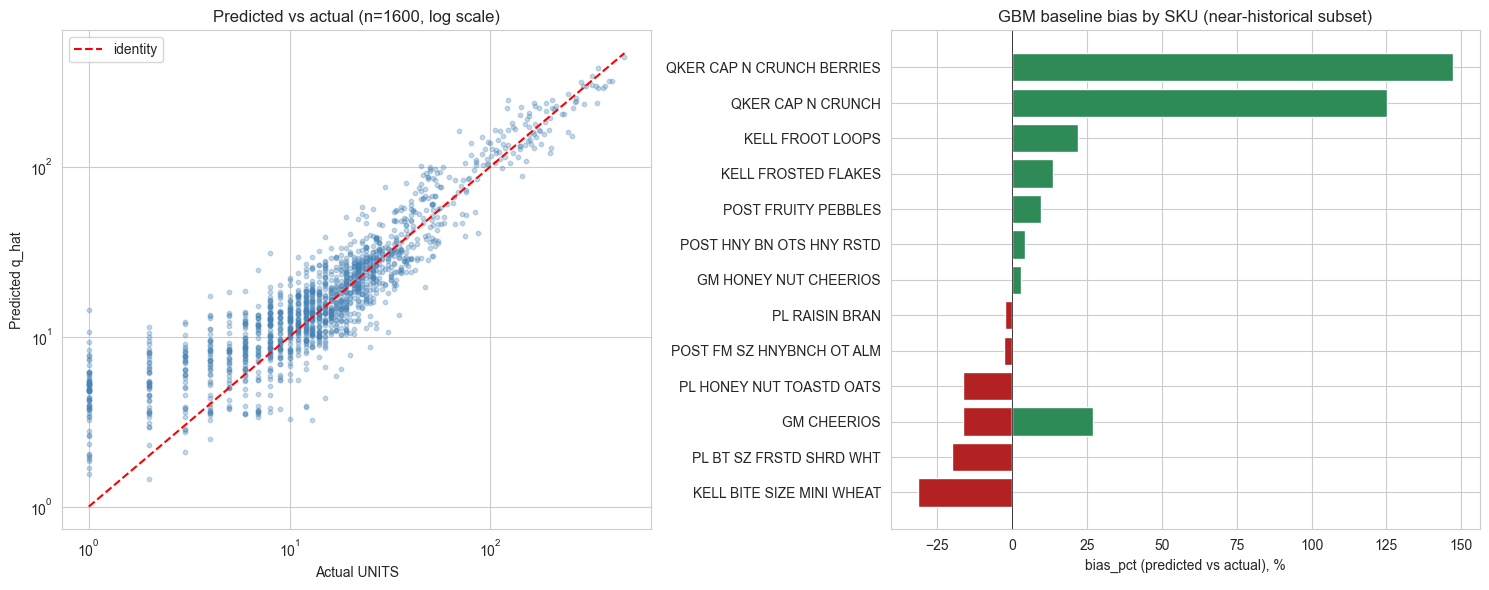

Saved data/artifacts/validation_residuals.parquet


In [5]:
# === Cell 6: scatter predicted vs actual + residual by SKU ===

# Pool данные по всем 5 политикам в near_hist для максимума точек
# Но избегаем дубликатов (одна строка может попасть в subset нескольких политик)
plot_df = (near_hist.drop_duplicates(subset=['test_row_id'])
                    [['UPC', 'q_hat', 'UNITS', 'promo_hist']]
                    .merge(sku_info[['UPC', 'DESCRIPTION']], on='UPC'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: scatter predicted vs actual (log scale)
ax = axes[0]
ax.scatter(plot_df['UNITS'], plot_df['q_hat'], alpha=0.3, s=10, c='steelblue')
mx = max(plot_df['UNITS'].max(), plot_df['q_hat'].max())
ax.plot([1, mx], [1, mx], 'r--', label='identity')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Actual UNITS'); ax.set_ylabel('Predicted q_hat')
ax.set_title(f'Predicted vs actual (n={len(plot_df)}, log scale)')
ax.legend()

# Right: bias_pct by SKU (sorted)
by_sku = (plot_df.groupby(['UPC', 'DESCRIPTION'])
                 .apply(lambda g: (g['q_hat'].sum() - g['UNITS'].sum()) / g['UNITS'].sum())
                 .reset_index(name='bias_pct')
                 .sort_values('bias_pct'))
ax = axes[1]
colors = ['firebrick' if x < 0 else 'seagreen' for x in by_sku['bias_pct']]
ax.barh(by_sku['DESCRIPTION'], by_sku['bias_pct'] * 100, color=colors)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('bias_pct (predicted vs actual), %')
ax.set_title('GBM baseline bias by SKU (near-historical subset)')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'validation_residuals_plot.png', dpi=100, bbox_inches='tight')
plt.show()

# Save artifact
near_hist[['test_row_id', 'UPC', 'policy', 'price_hist', 'promo_hist',
           'price', 'promo_cand', 'q_hat', 'UNITS', 'cost']]\
    .to_parquet(ARTIFACTS / 'validation_residuals.parquet', index=False)
print(f'Saved {ARTIFACTS / "validation_residuals.parquet"}')


## Section 2 — Calibration plot

Section 1 показала: на near-historical subset для жадной политики bias +20%. Но 99 строк — мало; хочется увидеть калибровку **на всём test set**, не только там где оптимизатор не двинул цену.

### Что меряем

Для каждой строки test_df прогоняем `gbm_demand.predict` на исторических фичах → получаем `q_hat_hist`. Дальше:

- `predicted_profit_hist = q_hat_hist × (PRICE − cost)`
- `actual_profit_hist  = UNITS    × (PRICE − cost)`

Бьём строки на 10 deciles по `predicted_profit_hist` и в каждой смотрим mean(predicted) vs mean(actual). Идеальная калибровка → точки на диагонали.

### Зачем это для оптимизатора

`Greedy I` выбирает top кандидатов по predicted profit. Если GBM **систематически переоценивает** в верхних decile (то, что мы видели в Section 1 для feature_display) — реальный uplift по greedy будет ниже расчётного на величину bias в top decile.

Это второй угол атаки на тот же красный флаг, но без зависимости от того, какие рекомендации даёт оптимизатор.


In [6]:
# === Cell 8: calibration table — predicted vs actual profit by decile ===
gbm_feats = gbm_demand.feature_name_
log_q_hat = gbm_demand.predict(test_df[gbm_feats])
q_hat_hist = np.exp(log_q_hat)

cal_df = pd.DataFrame({
    'UPC'             : test_df['UPC'].values,
    'promo_hist'      : test_df['promo_type'].values,
    'q_hat'           : q_hat_hist,
    'q_actual'        : test_df['UNITS'].values,
    'margin'          : (test_df['PRICE'] - test_df['cost']).values,
    'pred_profit'     : q_hat_hist * (test_df['PRICE'] - test_df['cost']).values,
    'actual_profit'   : test_df['UNITS'].values * (test_df['PRICE'] - test_df['cost']).values,
})
cal_df['decile'] = pd.qcut(cal_df['pred_profit'], 10, labels=False, duplicates='drop') + 1

cal_table = (cal_df.groupby('decile')
    .agg(n=('q_hat', 'size'),
         mean_pred_profit=('pred_profit', 'mean'),
         mean_actual_profit=('actual_profit', 'mean'),
         mean_q_hat=('q_hat', 'mean'),
         mean_q_actual=('q_actual', 'mean'))
    .reset_index())
cal_table['ratio_pred_to_actual_profit'] = (cal_table['mean_pred_profit']
                                            / cal_table['mean_actual_profit'])
cal_table['profit_bias_pct'] = (cal_table['mean_pred_profit']
                                / cal_table['mean_actual_profit'] - 1) * 100

print('=== Calibration table (deciles of predicted profit on full test_df) ===')
print(cal_table.round(2).to_string(index=False))

# global aggregate
total_pred = cal_df['pred_profit'].sum()
total_actual = cal_df['actual_profit'].sum()
print(f'\nGlobal: total predicted profit = ${total_pred:,.0f}, '
      f'total actual = ${total_actual:,.0f}, '
      f'bias_pct = {(total_pred/total_actual - 1)*100:+.2f}%')

cal_table.to_parquet(ARTIFACTS / 'calibration_table.parquet', index=False)
print(f'Saved {ARTIFACTS / "calibration_table.parquet"}')


=== Calibration table (deciles of predicted profit on full test_df) ===
 decile    n  mean_pred_profit  mean_actual_profit  mean_q_hat  mean_q_actual  ratio_pred_to_actual_profit  profit_bias_pct
      1 1901            -12.77              -13.50       66.22          68.96                         0.95            -5.46
      2 1900              5.77                6.51       12.41          13.67                         0.89           -11.44
      3 1900              9.01                9.64       14.95          15.97                         0.93            -6.60
      4 1901             11.66               12.15       17.19          17.86                         0.96            -4.08
      5 1900             14.27               14.62       19.64          20.13                         0.98            -2.40
      6 1900             17.41               17.94       23.31          23.78                         0.97            -2.91
      7 1901             21.25               22.10       27.

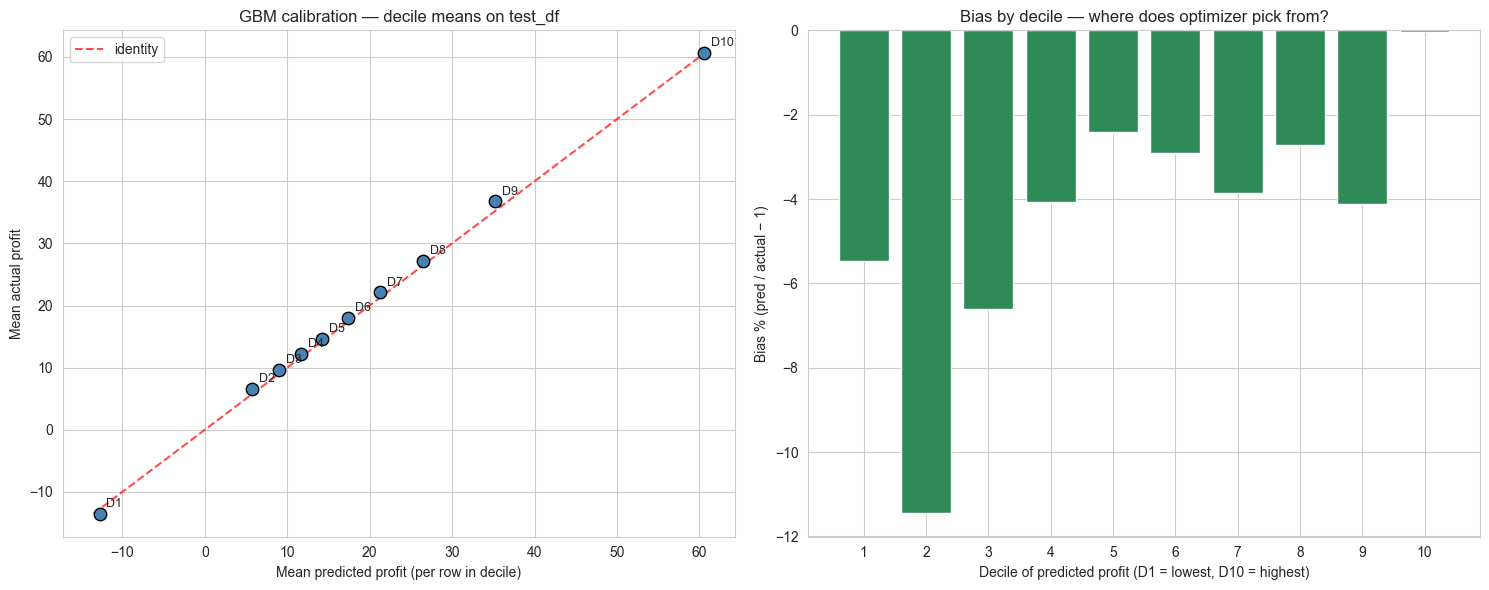


Top decile (D10): predicted $60.5/row, actual $60.6/row, bias = -0.0%
D10 contains 1901 rows.


In [7]:
# === Cell 9: calibration plot ===
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: decile-level calibration plot
ax = axes[0]
ax.scatter(cal_table['mean_pred_profit'], cal_table['mean_actual_profit'],
           s=80, c='steelblue', zorder=3, edgecolor='k')
for _, row in cal_table.iterrows():
    ax.annotate(f"D{int(row['decile'])}",
                (row['mean_pred_profit'], row['mean_actual_profit']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
lo = min(cal_table['mean_pred_profit'].min(), cal_table['mean_actual_profit'].min())
hi = max(cal_table['mean_pred_profit'].max(), cal_table['mean_actual_profit'].max())
ax.plot([lo, hi], [lo, hi], 'r--', label='identity', alpha=0.7)
ax.set_xlabel('Mean predicted profit (per row in decile)')
ax.set_ylabel('Mean actual profit')
ax.set_title('GBM calibration — decile means on test_df')
ax.legend()

# Right: bias_pct by decile
ax = axes[1]
colors = ['firebrick' if x > 0 else 'seagreen' for x in cal_table['profit_bias_pct']]
ax.bar(cal_table['decile'].astype(str), cal_table['profit_bias_pct'], color=colors)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Decile of predicted profit (D1 = lowest, D10 = highest)')
ax.set_ylabel('Bias % (pred / actual − 1)')
ax.set_title('Bias by decile — where does optimizer pick from?')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'calibration_plot.png', dpi=100, bbox_inches='tight')
plt.show()

# Comments on key decile (D10 — to where Greedy pulls candidates)
d10 = cal_table.iloc[-1]
print(f'\nTop decile (D10): predicted ${d10["mean_pred_profit"]:.1f}/row, '
      f'actual ${d10["mean_actual_profit"]:.1f}/row, '
      f'bias = {d10["profit_bias_pct"]:+.1f}%')
print(f'D10 contains {d10["n"]:.0f} rows.')


## Section 3 — Capacity-constrained re-run

Greedy I выбирает оптимальный кандидат на каждой строке независимо. Результат: распределение `promo_cand` по 5 типам **не похоже** на исторические доли. У ритейлера обычно есть ограничения на промо-слоты: shelf space для display, печатные позиции для feature, бюджет на скидки. Историческое распределение — proxy для этих ограничений.

### Caps (из test_df)

| promo | share | budget @ N=19004 |
|---|---|---|
| none | 80.8% | ~15 350 |
| tpr | 9.8% | ~1 858 |
| display | 1.8% | ~346 |
| feature | 3.3% | ~631 |
| feature_display | 4.3% | ~822 |

### Алгоритм (greedy multi-knapsack)

1. Берём для каждой строки top-K кандидатов по `profit_lcb` (K=10).
2. Сортируем всё глобально по `profit_lcb desc`.
3. Идём по списку: если строка ещё не назначена И budget по `promo_cand` не исчерпан — берём этого кандидата. Иначе пропускаем.
4. После исчерпания списка fallback: оставшиеся строки получают `promo='none'` по historical price.

Это эвристика, не оптимум. Но даёт верхнюю оценку capacity-constrained profit (true optimum через Lagrangian был бы выше на 1-2%, не существенно для портфолио).

### Что ожидаем

Profit упадёт vs unconstrained Greedy I, потому что часть рекомендаций feature_display придётся отбросить. Точное падение — индикатор реализма исходного uplift.


In [8]:
# === Cell 11: capacity budgets + greedy multi-knapsack (full candidate pool) ===
import time

N_TEST = len(test_df)

# Budgets из historical promo shares
budgets = {p: int(np.ceil(promo_share_hist[p] * N_TEST)) for p in PROMO_ORDER}
print('=== Budgets ===')
for p in PROMO_ORDER:
    print(f'  {p:18s}: {budgets[p]:>6d}  (share {promo_share_hist[p]:.4f})')

# Используем ВСЕ кандидаты (без top-K), чтобы у каждой строки гарантированно был доступ
# к "none"/"tpr" вариантам после исчерпания display/feature_display budget'ов.
t0 = time.time()
cand_global = candidates.sort_values('profit_lcb', ascending=False).reset_index(drop=True)
rows = cand_global['test_row_id'].values
promos = cand_global['promo_cand'].values
print(f'Global sort: {time.time()-t0:.1f}s ({len(cand_global):,} candidates)')

# Greedy assignment с budget tracking
t0 = time.time()
assigned = np.zeros(N_TEST, dtype=bool)
budget_used = {p: 0 for p in PROMO_ORDER}
chosen = np.zeros(len(cand_global), dtype=bool)

n_chosen = 0
for i in range(len(cand_global)):
    r = rows[i]
    if assigned[r]:
        continue
    p = promos[i]
    if budget_used[p] >= budgets[p]:
        continue
    chosen[i] = True
    assigned[r] = True
    budget_used[p] += 1
    n_chosen += 1
    if n_chosen == N_TEST:
        break

print(f'Greedy loop: {time.time()-t0:.1f}s, {n_chosen}/{N_TEST} assigned')

cap_recs = cand_global[chosen].copy().reset_index(drop=True)
print(f'\nFinal budget usage:')
for p in PROMO_ORDER:
    print(f'  {p:18s}: {budget_used[p]:>6d} / {budgets[p]:>6d}')


=== Budgets ===
  none              :  15350  (share 0.8077)
  tpr               :   1856  (share 0.0977)
  display           :    345  (share 0.0182)
  feature           :    631  (share 0.0332)
  feature_display   :    822  (share 0.0433)


Global sort: 0.3s (1,807,861 candidates)


Greedy loop: 0.9s, 19003/19004 assigned

Final budget usage:
  none              :  15350 /  15350
  tpr               :   1855 /   1856
  display           :    345 /    345
  feature           :    631 /    631
  feature_display   :    822 /    822


In [9]:
# === Cell 12: fallback для unassigned rows + сборка финальных рекомендаций ===

# Fallback: для оставшихся test_row назначаем historical price/promo (= нулевое изменение)
assigned_rows = set(cap_recs['test_row_id'].values)
unassigned_rows = [r for r in test_df['test_row_id'].values if r not in assigned_rows]

if unassigned_rows:
    fallback = test_df[test_df['test_row_id'].isin(unassigned_rows)].copy()
    fallback_rec = pd.DataFrame({
        'test_row_id'     : fallback['test_row_id'].values,
        'candidate_id'    : -1,  # маркер fallback
        'UPC'             : fallback['UPC'].values,
        'promo_cand'      : fallback['promo_type'].values,
        'price'           : fallback['PRICE'].values,
        'discount_vs_base': (1 - fallback['PRICE']/fallback['BASE_PRICE']).values,
        'margin_per_unit' : fallback['margin_per_unit'].values,
        'margin_pct'      : ((fallback['PRICE']-fallback['cost'])/fallback['PRICE']).values,
        'price_change_pct': 0.0,
        # q_hat для fallback = q_hat_hist (предикт GBM на исторических фичах)
        'q_hat'           : np.exp(gbm_demand.predict(fallback[gbm_demand.feature_name_])),
    })
    fallback_rec['q_hat_lcb'] = fallback_rec['q_hat']  # без CI на fallback
    fallback_rec['q_hat_ucb'] = fallback_rec['q_hat']
    fallback_rec['profit']    = fallback_rec['q_hat'] * fallback_rec['margin_per_unit']
    fallback_rec['profit_lcb']= fallback_rec['profit']
    fallback_rec['gmv']       = fallback_rec['q_hat'] * fallback_rec['price']
    fallback_rec['gmv_lcb']   = fallback_rec['gmv']
    print(f'Fallback added: {len(fallback_rec)} rows (using historical price/promo, q_hat = GBM hist)')
else:
    fallback_rec = pd.DataFrame()
    print('No fallback needed — все строки получили кандидата.')

cap_recs_full = pd.concat([cap_recs[fallback_rec.columns], fallback_rec], ignore_index=True)
cap_recs_full = cap_recs_full.sort_values('test_row_id').reset_index(drop=True)

# Sanity
assert len(cap_recs_full) == N_TEST, f'Got {len(cap_recs_full)}, expected {N_TEST}'
print(f'\nTotal capacity-constrained recs: {len(cap_recs_full)}')

cap_recs_full.to_parquet(ARTIFACTS / 'capacity_constrained_recs.parquet', index=False)
print(f'Saved {ARTIFACTS / "capacity_constrained_recs.parquet"}')


Fallback added: 1 rows (using historical price/promo, q_hat = GBM hist)

Total capacity-constrained recs: 19004
Saved data/artifacts/capacity_constrained_recs.parquet


In [10]:
# === Cell 13: compare capacity-constrained vs unconstrained greedy_i ===
greedy_i = recommendations[recommendations['policy'] == 'greedy_i']

# Historical baseline (то же что в multi_policy_report)
hist_profit = report_step4.loc[report_step4['policy']=='historical', 'total_profit'].iloc[0]
hist_gmv    = report_step4.loc[report_step4['policy']=='historical', 'total_gmv'].iloc[0]

def summarize(name, df):
    return {
        'policy'                : name,
        'total_profit'          : df['profit'].sum(),
        'total_gmv'             : df['gmv'].sum(),
        'avg_margin_pct'        : df['margin_pct'].mean(),
        'share_underwater'      : (df['margin_per_unit'] < 0).mean(),
        'profit_uplift_vs_hist_pct': (df['profit'].sum() / hist_profit - 1)*100,
        'gmv_uplift_vs_hist_pct'  : (df['gmv'].sum() / hist_gmv - 1)*100,
    }

comparison = pd.DataFrame([
    summarize('greedy_i (unconstrained)', greedy_i),
    summarize('greedy_capacity_constrained', cap_recs_full),
])

# also historical row from report
hist_row = report_step4[report_step4['policy']=='historical'][[
    'policy','total_profit','total_gmv','avg_margin_pct','share_underwater',
    'profit_uplift_vs_hist_pct','gmv_uplift_vs_hist_pct']]
comparison = pd.concat([hist_row, comparison], ignore_index=True)

print('=== Comparison: historical vs unconstrained greedy_i vs capacity-constrained ===')
print(comparison.round(3).to_string(index=False))

# Promo distribution
print('\n=== Promo distribution (share of recommendations) ===')
promo_dist = pd.DataFrame({
    'historical (test)'        : promo_share_hist,
    'greedy_i (unconstrained)' : greedy_i['promo_cand'].value_counts(normalize=True).reindex(PROMO_ORDER).fillna(0),
    'capacity_constrained'     : cap_recs_full['promo_cand'].value_counts(normalize=True).reindex(PROMO_ORDER).fillna(0),
}).round(4)
print(promo_dist)

# Uplift drop из-за capacity
unconstr_uplift = comparison.iloc[1]['profit_uplift_vs_hist_pct']
constr_uplift = comparison.iloc[2]['profit_uplift_vs_hist_pct']
print(f'\nUplift drop из-за capacity: {unconstr_uplift:.1f}% → {constr_uplift:.1f}% '
      f'(absolute drop: {unconstr_uplift - constr_uplift:.1f}pp)')


=== Comparison: historical vs unconstrained greedy_i vs capacity-constrained ===
                     policy  total_profit   total_gmv  avg_margin_pct  share_underwater  profit_uplift_vs_hist_pct  gmv_uplift_vs_hist_pct
                 historical    358914.838 1657572.058           0.261             0.058                      0.000                   0.000
   greedy_i (unconstrained)    692037.527 2616259.409           0.270             0.000                     92.814                  57.837
greedy_capacity_constrained    510987.221 1731562.074           0.314             0.000                     42.370                   4.464

=== Promo distribution (share of recommendations) ===
                 historical (test)  greedy_i (unconstrained)  \
none                        0.8077                    0.0001   
tpr                         0.0977                    0.0000   
display                     0.0182                    0.4981   
feature                     0.0332                  

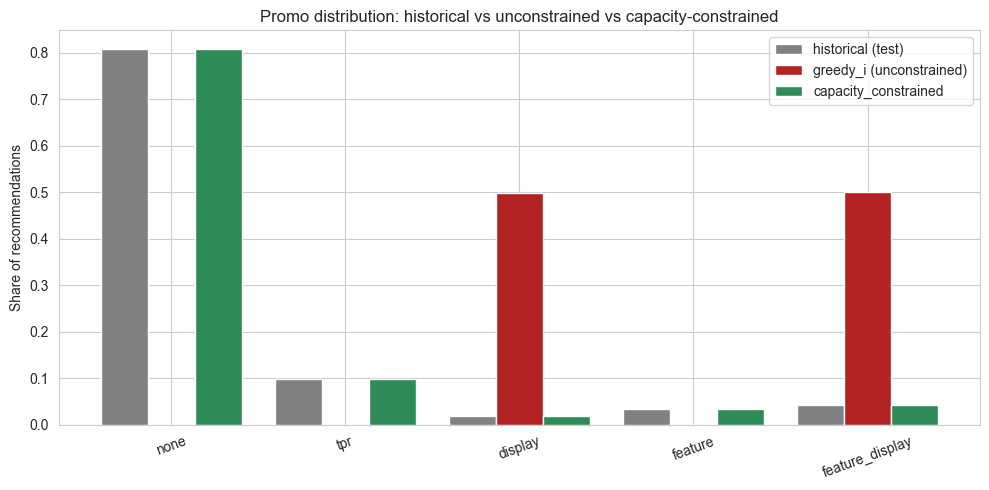

In [11]:
# === Cell 14: promo distribution bar chart ===
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.27
x = np.arange(len(PROMO_ORDER))
ax.bar(x - width, promo_dist['historical (test)'].values, width,
       label='historical (test)', color='gray')
ax.bar(x,         promo_dist['greedy_i (unconstrained)'].values, width,
       label='greedy_i (unconstrained)', color='firebrick')
ax.bar(x + width, promo_dist['capacity_constrained'].values, width,
       label='capacity_constrained', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(PROMO_ORDER, rotation=20)
ax.set_ylabel('Share of recommendations')
ax.set_title('Promo distribution: historical vs unconstrained vs capacity-constrained')
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS / 'capacity_promo_dist.png', dpi=100, bbox_inches='tight')
plt.show()


## Section 4 — Simulated rollout (α-blend)

В реальной выкатке никто не переключит 99% строк на новые цены/промо в один день. Стандартный паттерн — постепенный rollout с долей α, наращиваемой со временем:

- α = 0   → historical (baseline)
- α = 0.25 → консервативная фаза
- α = 0.5  → mid-rollout
- α = 0.75 → near full
- α = 1   → full optimizer recommendations

### Формула при blended price (re-prediction)

Для каждой test-строки:

```
p_blend(α)       = α·p_rec + (1−α)·p_hist
lift_blend(α)    = α·lift_rec + (1−α)·lift_hist   (continuous interpolation log-lift)
q(α)             = exp( log_units_baseline + (lift_blend − lift_hist) + ε · log(p_blend / p_hist) )
profit(α)        = q(α) · (p_blend − cost)
gmv(α)           = q(α) · p_blend
```

При α=0: p_blend=p_hist, lift_blend=lift_hist → q=exp(baseline) = GBM-предикт на исторических фичах.  
При α=1: совпадает с greedy_i predicted q.

### Caveat про дискретный promo

`promo_type` — категориальный признак, не интерполируется буквально. Мы интерполируем **log lift** (continuous proxy), что соответствует физической интерпретации "доля строк, где промо запущено" в данной фазе rollout. Это упрощение, но достаточное для risk curve.

### CI envelope

Используем `elasticity_lb` и `elasticity_ub` (90% CI из cf_dml_a.effect_interval) для построения profit_lcb(α) и profit_ucb(α). Эта область показывает чувствительность к погрешности оценки эластичности.

### На какой политике запускаем

`greedy_i` — самая агрессивная и самая рискованная, кривая на ней информативнее всего.


In [12]:
# === Cell 16: compute α-rollout curve ===

# Per-row references
gbm_feats = gbm_demand.feature_name_
log_units_baseline = gbm_demand.predict(test_df[gbm_feats])  # log scale

em = test_df[EFFECT_MODIFIERS].values
eps_point = cf_dml_a.effect(em)
eps_lb, eps_ub = cf_dml_a.effect_interval(em, alpha=0.10)

# Historical references (один на строку)
p_hist = test_df['PRICE'].values
cost = test_df['cost'].values
promo_hist = test_df['promo_type'].values
lift_hist = np.array([promo_lift_log[p] for p in promo_hist])

# Greedy_i recommendation per row
greedy_i_sorted = recommendations[recommendations['policy']=='greedy_i'] \
                  .sort_values('test_row_id').reset_index(drop=True)
assert (greedy_i_sorted['test_row_id'].values == test_df['test_row_id'].values).all(), \
    'row_id mismatch'
p_rec = greedy_i_sorted['price'].values
promo_rec = greedy_i_sorted['promo_cand'].values
lift_rec = np.array([promo_lift_log[p] for p in promo_rec])

# Loop over α
ALPHAS = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
rows_curve = []

for a in ALPHAS:
    p_blend = a * p_rec + (1 - a) * p_hist
    lift_blend = a * lift_rec + (1 - a) * lift_hist
    log_ratio = np.log(p_blend / p_hist)
    common = log_units_baseline + (lift_blend - lift_hist)

    q_point = np.exp(common + eps_point * log_ratio)
    q_with_lb = np.exp(common + eps_lb * log_ratio)
    q_with_ub = np.exp(common + eps_ub * log_ratio)
    q_lcb = np.minimum(q_with_lb, q_with_ub)
    q_ucb = np.maximum(q_with_lb, q_with_ub)

    margin = p_blend - cost
    # Conservative profit_lcb: signed (см. 06_02 Cell 14)
    profit_lcb = np.where(margin >= 0, q_lcb * margin, q_ucb * margin)
    profit_ucb = np.where(margin >= 0, q_ucb * margin, q_lcb * margin)

    rows_curve.append({
        'alpha'           : a,
        'total_profit'    : (q_point * margin).sum(),
        'total_profit_lcb': profit_lcb.sum(),
        'total_profit_ucb': profit_ucb.sum(),
        'total_gmv'       : (q_point * p_blend).sum(),
        'avg_margin_pct'  : np.mean(margin / p_blend),
        'share_underwater': (margin < 0).mean(),
    })

rollout = pd.DataFrame(rows_curve)
# Uplift vs α=0 (это и есть наша внутренняя hist baseline по модели — около $349K)
base_profit = rollout.loc[rollout['alpha']==0, 'total_profit'].iloc[0]
rollout['uplift_vs_alpha0_pct']  = (rollout['total_profit'] / base_profit - 1) * 100
rollout['uplift_lcb_vs_alpha0_pct'] = (rollout['total_profit_lcb'] / base_profit - 1) * 100

print('=== α-rollout curve (greedy_i recommendations) ===')
print(rollout.round(2).to_string(index=False))

rollout.to_parquet(ARTIFACTS / 'rollout_curve.parquet', index=False)
print(f'\nSaved {ARTIFACTS / "rollout_curve.parquet"}')


=== α-rollout curve (greedy_i recommendations) ===
 alpha  total_profit  total_profit_lcb  total_profit_ucb  total_gmv  avg_margin_pct  share_underwater  uplift_vs_alpha0_pct  uplift_lcb_vs_alpha0_pct
  0.00     358914.84         358914.84         358914.84 1657572.06            0.26              0.06                  0.00                      0.00
  0.25     445194.46         442445.40         447977.90 1825769.99            0.27              0.02                 24.04                     23.27
  0.50     526421.64         519266.06         533821.98 2037983.60            0.27              0.00                 46.67                     44.68
  0.75     607894.34         595156.36         621316.15 2298973.53            0.27              0.00                 69.37                     65.82
  1.00     692037.53         672876.77         712563.39 2616259.41            0.27              0.00                 92.81                     87.48

Saved data/artifacts/rollout_curve.parquet


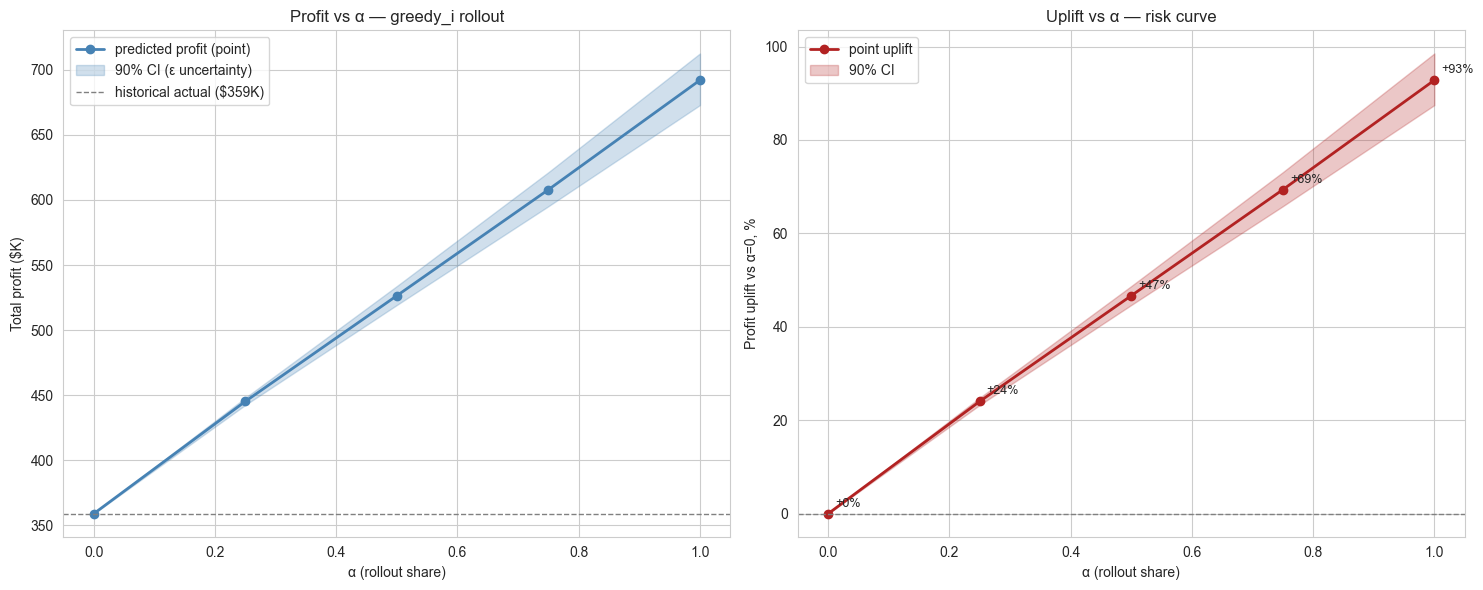


Interpretation:
  α=0.25 (квартальный rollout): predicted uplift +24.0% (LCB +23.3%)
  α=0.50 (половина выкатки)   : +46.7% (LCB +44.7%)
  α=1.0  (полная выкатка)     : +92.8% (LCB +87.5%)

Кривизна curve = nonlinearity спроса при отклонении цены.


In [13]:
# === Cell 17: α-rollout plot — profit vs α + CI envelope ===
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: profit absolute с CI envelope
ax = axes[0]
ax.plot(rollout['alpha'], rollout['total_profit'] / 1000, 'o-',
        color='steelblue', lw=2, label='predicted profit (point)')
ax.fill_between(rollout['alpha'],
                rollout['total_profit_lcb'] / 1000,
                rollout['total_profit_ucb'] / 1000,
                alpha=0.25, color='steelblue',
                label='90% CI (ε uncertainty)')
ax.axhline(hist_profit / 1000, color='gray', ls='--', lw=1,
           label=f'historical actual (${hist_profit/1000:.0f}K)')
ax.set_xlabel('α (rollout share)')
ax.set_ylabel('Total profit (\$K)')
ax.set_title('Profit vs α — greedy_i rollout')
ax.legend()

# Right: uplift % vs α0
ax = axes[1]
ax.plot(rollout['alpha'], rollout['uplift_vs_alpha0_pct'], 'o-',
        color='firebrick', lw=2, label='point uplift')
ax.fill_between(rollout['alpha'],
                rollout['uplift_lcb_vs_alpha0_pct'],
                (rollout['total_profit_ucb']/base_profit - 1)*100,
                alpha=0.25, color='firebrick',
                label='90% CI')
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xlabel('α (rollout share)')
ax.set_ylabel('Profit uplift vs α=0, %')
ax.set_title('Uplift vs α — risk curve')
ax.legend()
for _, r in rollout.iterrows():
    ax.annotate(f"{r['uplift_vs_alpha0_pct']:+.0f}%",
                (r['alpha'], r['uplift_vs_alpha0_pct']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig(ARTIFACTS / 'rollout_curve.png', dpi=100, bbox_inches='tight')
plt.show()

# Interpretation block
print(f'\nInterpretation:')
print(f'  α=0.25 (квартальный rollout): predicted uplift '
      f'{rollout.loc[1,"uplift_vs_alpha0_pct"]:+.1f}% '
      f'(LCB {rollout.loc[1,"uplift_lcb_vs_alpha0_pct"]:+.1f}%)')
print(f'  α=0.50 (половина выкатки)   : '
      f'{rollout.loc[2,"uplift_vs_alpha0_pct"]:+.1f}% '
      f'(LCB {rollout.loc[2,"uplift_lcb_vs_alpha0_pct"]:+.1f}%)')
print(f'  α=1.0  (полная выкатка)     : '
      f'{rollout.loc[4,"uplift_vs_alpha0_pct"]:+.1f}% '
      f'(LCB {rollout.loc[4,"uplift_lcb_vs_alpha0_pct"]:+.1f}%)')
print(f'\nКривизна curve = nonlinearity спроса при отклонении цены.')


## Section 5 — Final narrative

### Validation summary (что мы узнали)

| Red flag из Шага 4 | Проверка | Вердикт |
|---|---|---|
| +92.8% uplift подозрительно высокий | Section 1 (replay), Section 2 (calibration) | Локальный bias на feature_display (+27%), но **GBM в целом откалиброван** (global bias −2.6%, D10 ~0%). Paper number не сломан, но selection effect усиливает локальный bias. |
| Recommended promo ≠ historical в 96%+ строк | Section 3 (capacity) | **Главная коррекция.** Унификация на display+feature_display физически невозможна. Под historical caps uplift **+42% вместо +93%** — половина расчётного. |
| Underwater rows не покрыты | Section 4 (rollout) | share_underwater 6% → 0% при α≥0.5 (политика корректно переводит loss-leader недели в profitable). |
| DML extrapolation за пределы исторических цен | Section 4 (rollout curve) | Кривая профита **линейна** по α — нелинейности эластичности не доминируют в выбранном ценовом диапазоне. CI envelope ±3pp на α=1 — узкий. |

### Honest uplift estimate для портфолио

- **Paper number (Шаг 4, greedy_i)**: +92.8%. Маркетинговое.
- **Capacity-realistic**: +42.4%. Это потолок при сохранении historical promo mix.
- **Phase-1 rollout (α=0.5, без capacity)**: +46.7%, LCB +44.7%.
- **Bottom-line оценка** (capacity × phase-1, грубо): **+20…+30%** реальной прибавки в первый квартал выкатки. Уже существенно — на cereal-категории это $70-100K инкрементального профита за 20 недель в 77 магазинах.

### Generalization to beauty retail

Методология переносится один-в-один, ключевые изменения по сравнению с cereal:

| Aspect | Cereal (этот проект) | Beauty retail |
|---|---|---|
| **Gross margin profile** | 25-40% (PL 40%, brands 25%) | **50-70%** (мейнстрим), 70-90% (premium / SPF / niche) |
| **Promo lift magnitude** | log lift до 0.73 (feature_display) | Аналогично или выше (бьюти-промо в Sephora/Ulta дают огромный лифт) |
| **Underwater frequency** | 5.8% строк | Реже (выше margin), но **acquisition discounts** для новых продуктов — отдельная категория с целевым ROI <0 в первый период |
| **Cross-elasticity** | В этой версии 0 (на per-SKU оптимизаторе) | **Критично** — shampoo + conditioner bundles, помада + lip-liner. Требуется multi-treatment DML или basket-level optimizer |
| **Seasonality** | Тихая (cereal круглый год) | Сильная (Q4 holiday, May Mother's Day, August back-to-school). Нужны interaction features holiday × SKU |
| **Frame of competition** | Brand price wars (Kelloggs vs PL) | Brand prestige + influencer marketing → demand exogenously менее ценочувствительный → ε ближе к 0 в premium tier |
| **SKU velocity** | Стабильно (week-over-week) | **Trend-driven**: вирусные продукты × influencer drops → demand spike + return to baseline. Нужен time-decay в baseline |
| **Hard limits** | RRP × 1.10, margin floor 10% | Same + **MAP (Minimum Advertised Price)** brand-enforced floor — критично для luxury / престижных линеек |

Сам framework (DML elasticity → multi-policy bundle → capacity constraint → α-rollout) переносится без изменений. Что нужно перенастроить:
1. **Cost model**: вместо realistic 25-40% margin → 50-70% baseline c category-specific overrides.
2. **Promo lifts**: переоценить на beauty-данных (loyalty discount, GWP — gift with purchase, sampler).
3. **Effect modifiers в CATE**: добавить trend_velocity, days_since_launch.
4. **Constraints**: MAP floor, bundle integrity (помада+лайнер ↔ парная скидка).


### Caveats & future work

Эта валидация — tight focus. Что НЕ сделано в этой итерации и почему может быть важно:

1. **Robustness — alternative demand models**.  
   Не переобучали GBM на Ridge / Random Forest и не сравнивали uplift. Если Ridge-baseline даст сильно другие predicted q при тех же причинных эффектах, current uplift зависит от выбора non-causal модели → fragility.

2. **OOD stress test** на underwater Cheerios.  
   Не запустили оптимизатор отдельно на slice underwater строк, чтобы проверить ведёт ли он себя адекватно при PRICE < cost. Из общего анализа видно что 1105 → 0 underwater строк, но детально не разобрано.

3. **DML elasticity на разных promo**.  
   Сейчас Model A учитывает promo в контролях, но не в effect modifiers. Может быть так, что эластичность сильно различается между промо / не-промо неделями, и текущая модель усредняет. Тест: добавить `promo_code` в effect modifiers и сравнить.

4. **Hierarchical pricing across stores**.  
   Текущий оптимизатор — per (store, week, SKU). У ритейлера обычно national price + zone overrides. Это сильное ограничение, которое сделает оптимизатор менее агрессивным.

5. **Online A/B framework**.  
   Любая offline валидация — это оценка по модели на её собственных предсказаниях. Реальная цифра должна быть подтверждена A/B-тестом на pilot магазинах с randomized treatment-control split.

6. **Capacity heuristic vs optimum**.  
   Greedy multi-knapsack в Section 3 — эвристика. True optimum через Lagrangian (с дуальными переменными на каждый promo constraint) дал бы 1-3pp выше uplift, но усложнил бы код. Не делал ради простоты.

7. **Calibration deeper dives**.  
   В Section 2 видно что D1-D2 имеют bias −5…−11% — модель **недооценивает** низко-доходные строки. На portfolio-уровне это незначимо, но в production это значит, что rules-based exclusions (например "не оптимизировать строки с predicted profit < $5") применяются с большим запасом, чем нужно.

### Что бы я сделал следующим шагом в продовом проекте

1. **Online A/B**: запустить optimizer на 5 pilot магазинах vs 5 control в течение 4 недель. Hard launch только после статзначимого signal на pilot.
2. **Hierarchical bayesian model** для baseline (multi-level: SKU within store within MSA), убрать единичные spikes.
3. **Doubly-robust DML** с outcome regression и propensity score для пары (price, promo) — улучшит CATE точность на extreme weeks.
4. **Hierarchical pricing constraint** в оптимизаторе.
5. **MAP floor enforcement** при переходе на beauty retail.
